In [67]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 


In [68]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [69]:
file_path = 'C:\\Users\\zalew\\OneDrive\\Desktop\\Projects\\Feature-Engineering-Building-ML-Pipeline-\\data\\cleaned_by_pipeline.csv'
df = pd.read_csv(file_path)

# Display basic information about dataset shape
shape_of_df = df.shape
print(f"Dataset shape: {shape_of_df[0]} rows × {shape_of_df[1]} columns")
shape_of_df

Dataset shape: 1523 rows × 10 columns


(1523, 10)

In [70]:
df.info()
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1523 entries, 0 to 1522
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Model_Year    1523 non-null   float64
 1   Mileage       1523 non-null   float64
 2   Doors         1523 non-null   float64
 3   Owner_Count   1523 non-null   float64
 4   Horsepower    1523 non-null   float64
 5   Brand         1523 non-null   str    
 6   Fuel_Type     1523 non-null   str    
 7   Transmission  1523 non-null   str    
 8   Engine_Size   1523 non-null   float64
 9   Price         1523 non-null   float64
dtypes: float64(7), str(3)
memory usage: 119.1 KB
   Model_Year   Mileage  Doors  Owner_Count  Horsepower  Brand Fuel_Type  \
0      2014.0  144011.0    2.0          1.0       356.0   Ford    petrol   
1      2014.0  101382.0    4.0          3.0       396.0  Honda    diesel   
2      2017.0  132385.0    2.0          2.0       243.0  Tesla  electric   
3      2014.0  102531.0    2.0    

In [71]:
column_names = list(df.columns)
missing_val_count=df.isna().sum()
missing_val_df=pd.DataFrame({
        'column_name': column_names,
     'missing_values': missing_val_count,
     "missing %": (missing_val_count / len(df) * 100).round(2)
})
missing_val_df_filtered = missing_val_df[missing_val_df["missing_values"] > 0]

if len(missing_val_df_filtered) > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x='column_name', y='missing_values', data=missing_val_df_filtered)
    plt.title('Missing Values Count by Column')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset")

No missing values found in the dataset


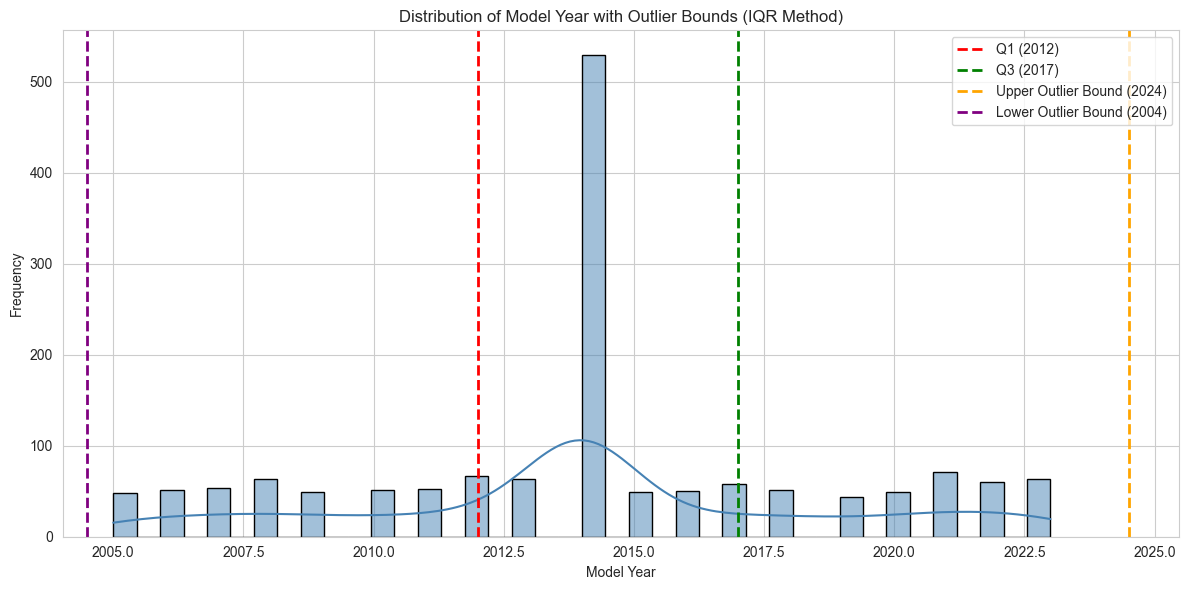

Model Year - Q1: 2012.0, Q3: 2017.0, IQR: 5.0, Upper Bound: 2024.5, Lower Bound: 2004.5


In [72]:
Q1 = df['Model_Year'].quantile(0.25)
Q3 = df['Model_Year'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['Model_Year'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Model Year with Outlier Bounds (IQR Method)')
plt.xlabel('Model Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Model Year - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [73]:
print(df['Mileage'].describe())

count      1523.000000
mean     101502.185161
std       49988.982141
min        5036.000000
25%       65090.500000
50%      102531.000000
75%      136536.500000
max      199904.000000
Name: Mileage, dtype: float64


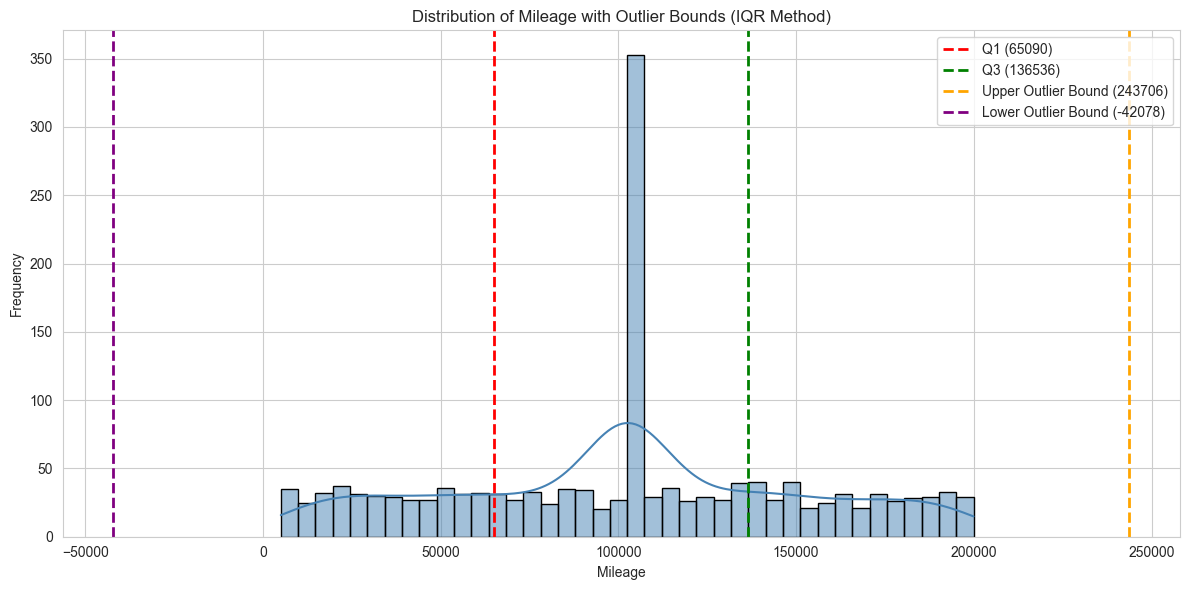

Mileage - Q1: 65090.5, Q3: 136536.5, IQR: 71446.0, Upper Bound: 243705.5, Lower Bound: -42078.5


In [74]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['Mileage'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Mileage with Outlier Bounds (IQR Method)')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mileage - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [75]:
print(df['Doors'].describe())

count    1523.000000
mean        2.781353
std         0.830667
min         2.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Doors, dtype: float64


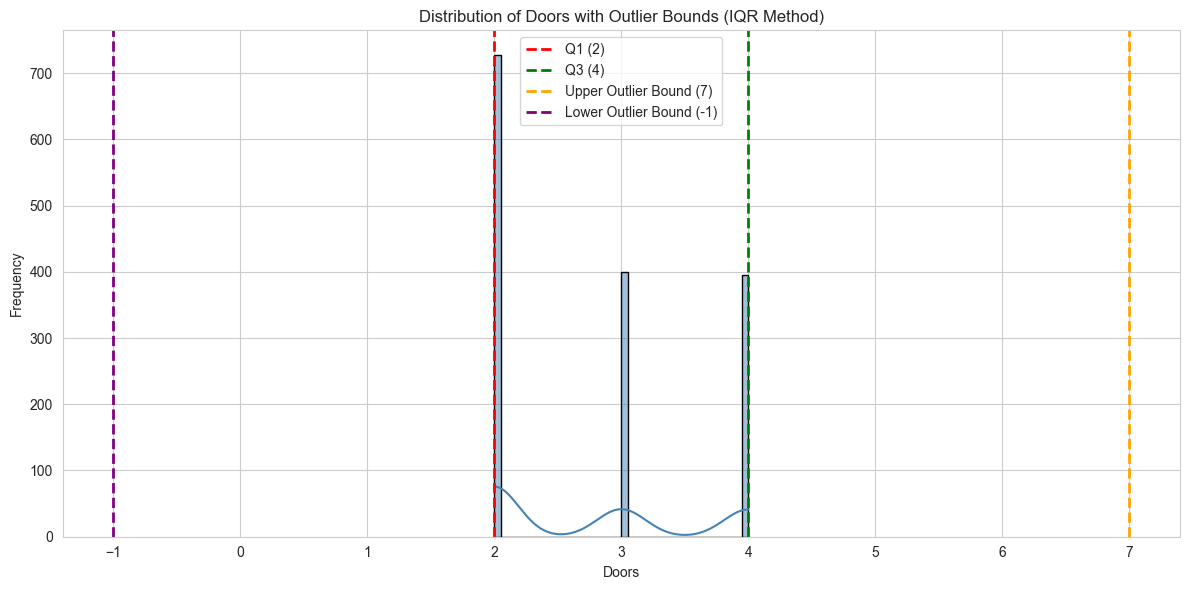

Doors - Q1: 2.0, Q3: 4.0, IQR: 2.0, Upper Bound: 7.0, Lower Bound: -1.0


In [76]:
Q1 = df['Doors'].quantile(0.25)
Q3 = df['Doors'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['Doors'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Doors with Outlier Bounds (IQR Method)')
plt.xlabel('Doors')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Doors - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [77]:
print(df['Owner_Count'].describe())

count    1523.000000
mean        2.811556
std         1.177682
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: Owner_Count, dtype: float64


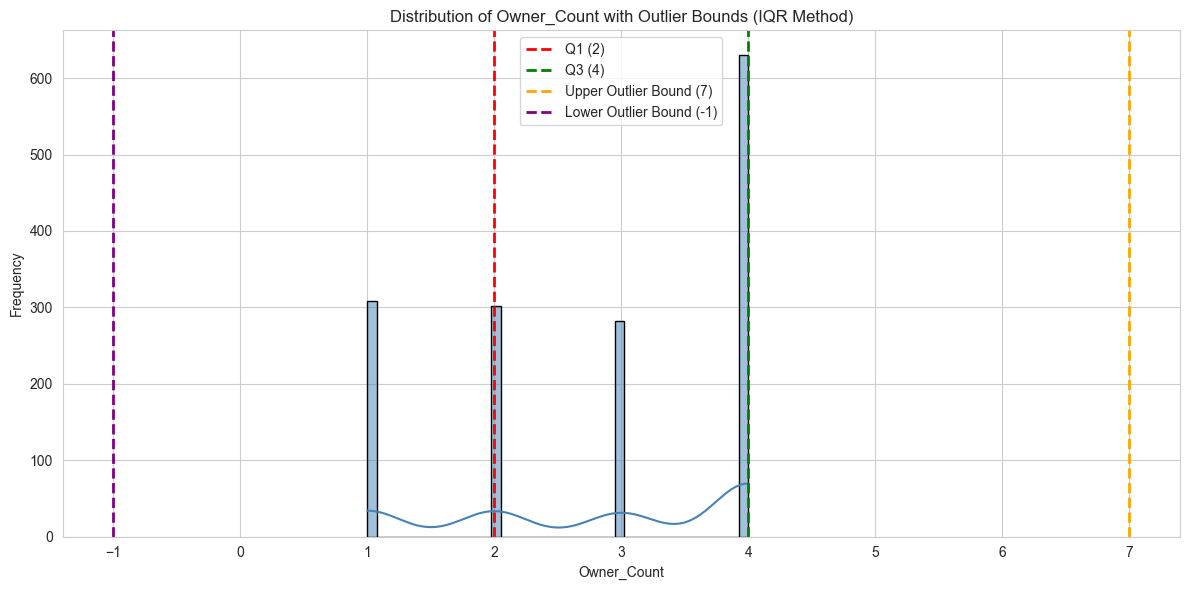

Owner_Count - Q1: 2.0, Q3: 4.0, IQR: 2.0, Upper Bound: 7.0, Lower Bound: -1.0


In [79]:
Q1 = df['Owner_Count'].quantile(0.25)
Q3 = df['Owner_Count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['Owner_Count'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Owner_Count with Outlier Bounds (IQR Method)')
plt.xlabel('Owner_Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Owner_Count - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [80]:
print(df['Horsepower'].describe())

count    1523.000000
mean      235.435325
std        84.259565
min        70.000000
25%       178.500000
50%       231.000000
75%       296.500000
max       399.000000
Name: Horsepower, dtype: float64


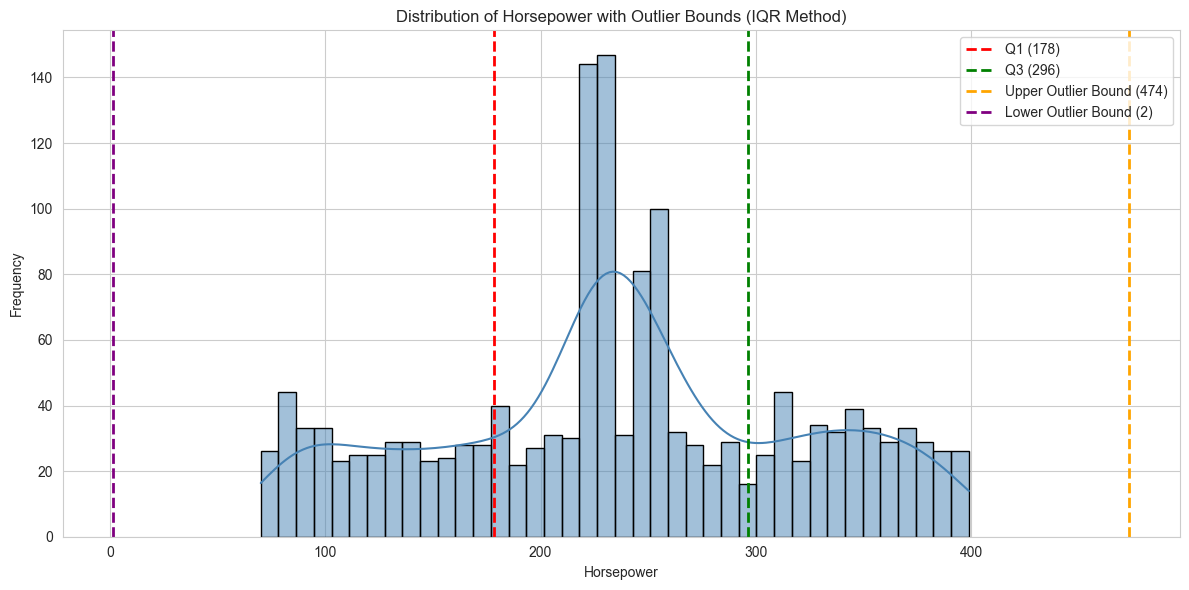

Horsepower - Q1: 178.5, Q3: 296.5, IQR: 118.0, Upper Bound: 473.5, Lower Bound: 1.5


In [81]:
Q1 = df['Horsepower'].quantile(0.25)
Q3 = df['Horsepower'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['Horsepower'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Horsepower with Outlier Bounds (IQR Method)')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Horsepower - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

In [82]:
print(df['Price'].describe())
print(df['Price'].value_counts())

count     1523.000000
mean     46208.733552
std       9226.081960
min      18911.550000
25%      39805.825000
50%      46281.000000
75%      52532.000000
max      70167.600000
Name: Price, dtype: float64
Price
61395.45    1
49188.90    1
47151.75    1
48857.70    1
51072.50    1
           ..
50180.65    1
51337.15    1
54418.15    1
45274.70    1
43479.80    1
Name: count, Length: 1523, dtype: int64


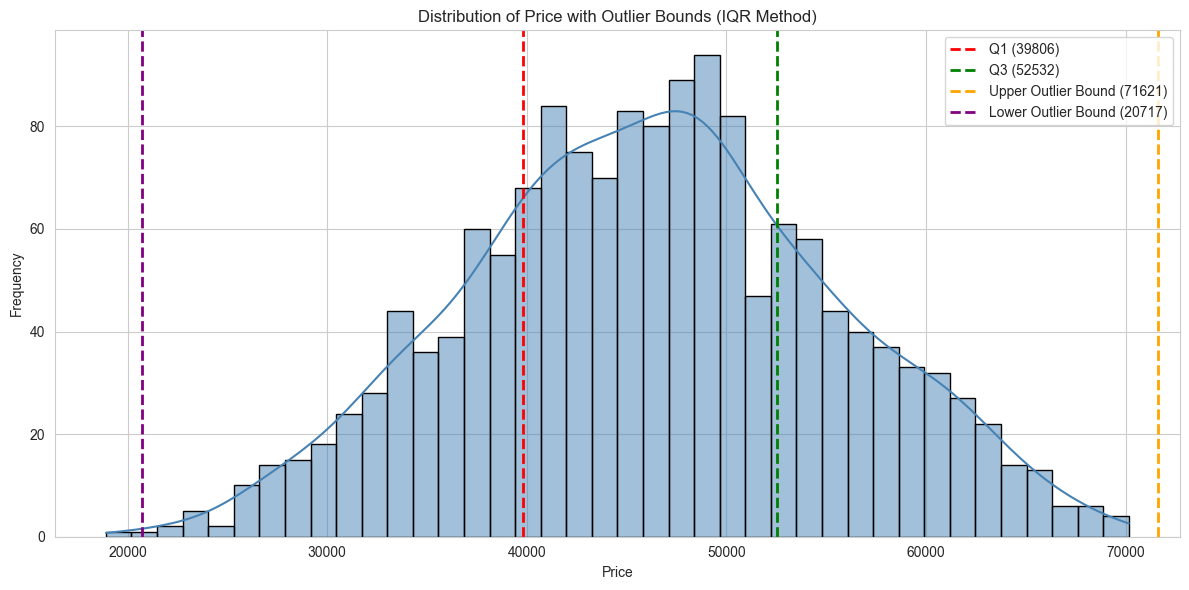

Price - Q1: 39805.825, Q3: 52532.0, IQR: 12726.175000000003, Upper Bound: 71621.26250000001, Lower Bound: 20716.562499999993


In [85]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

plt.figure(figsize=(12, 6))
sns.histplot(df['Price'], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.axvline(Q1, color='red', linestyle='--', linewidth=2, label=f'Q1 ({Q1:.0f})')
plt.axvline(Q3, color='green', linestyle='--', linewidth=2, label=f'Q3 ({Q3:.0f})')
plt.axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper Outlier Bound ({upper_bound:.0f})')
plt.axvline(lower_bound, color='purple', linestyle='--', linewidth=2, label=f'Lower Outlier Bound ({lower_bound:.0f})')
plt.legend()
plt.title('Distribution of Price with Outlier Bounds (IQR Method)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Price - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Upper Bound: {upper_bound}, Lower Bound: {lower_bound}")

count       1523
unique         6
top       Toyota
freq         266
Name: Brand, dtype: object 

Brand
Toyota     266
Honda      260
BMW        260
Hyundai    252
Tesla      243
Ford       242
Name: count, dtype: int64


C:\Users\zalew\AppData\Local\Temp\ipykernel_24160\3425096628.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Brand', data=df, order=df['Brand'].value_counts().index, palette='viridis')


Text(0.5, 1.0, 'Distribution of Car Brands')

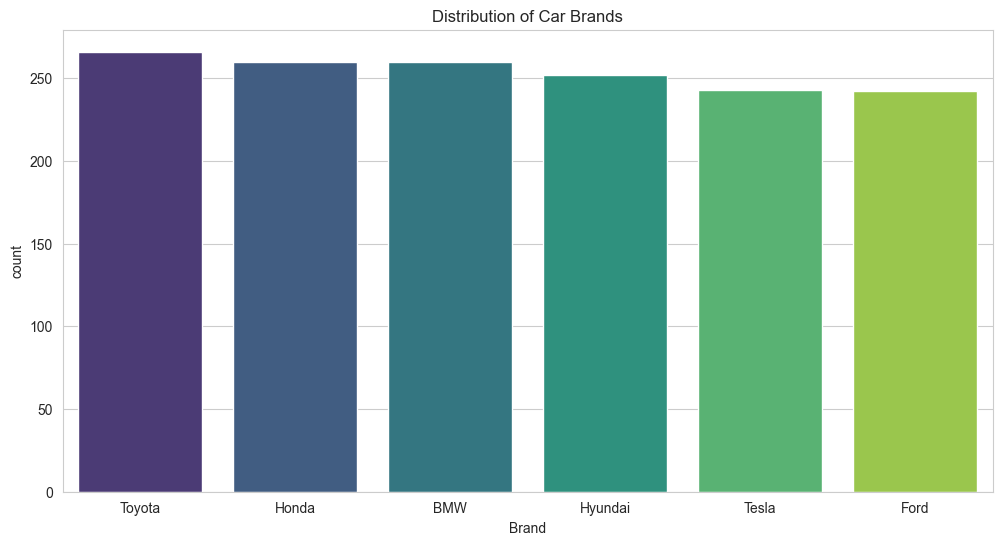

In [86]:
print(f'{df['Brand'].describe()} \n')


print(df['Brand'].value_counts())

sns.countplot(x='Brand', data=df, order=df['Brand'].value_counts().index, palette='viridis')
plt.title('Distribution of Car Brands')

count    1523.000000
mean        2.977347
std         1.019304
min         1.000000
25%         2.300000
50%         3.000000
75%         3.700000
max         5.000000
Name: Engine_Size, dtype: float64 

[4.1 1.4 3.6 3.  3.9 2.7 3.7 4.7 2.2 1.2 3.2 1.3 3.8 3.4 4.6 1.8 2.6 4.9
 4.2 2.1 1.6 2.4 1.9 4.3 5.  2.3 4.  1.7 3.3 3.5 4.4 4.5 2.9 3.1 2.5 1.1
 2.8 1.5 4.8 2.  1. ]


Text(0.5, 1.0, 'Distribution of Engine Size')

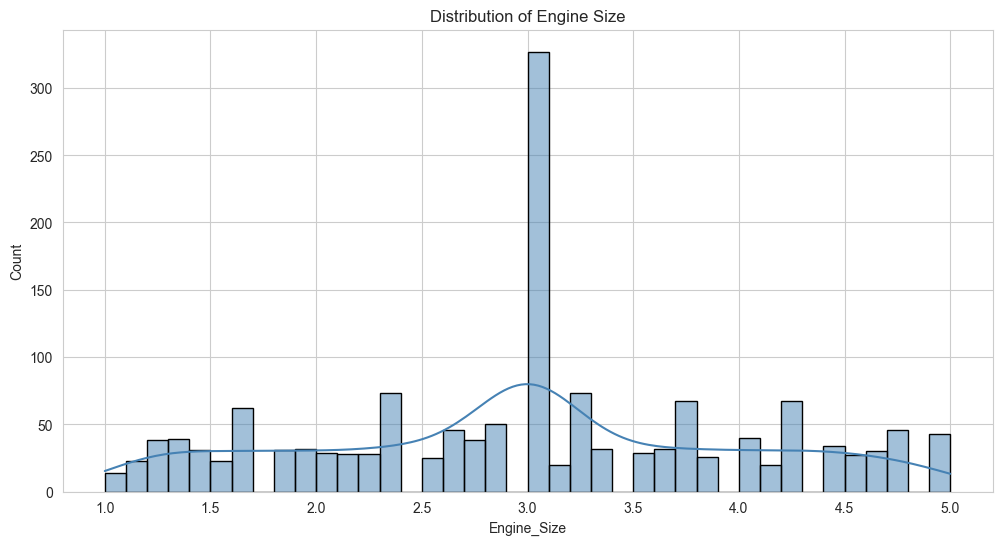

In [87]:
print(f'{df["Engine_Size"].describe()} \n')
print(df["Engine_Size"].unique())
sns.histplot(df["Engine_Size"], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.title('Distribution of Engine Size')

In [88]:
print(f'{df["Fuel_Type"].describe()} \n')
print(df["Fuel_Type"].unique())

count         1523
unique           4
top       electric
freq           567
Name: Fuel_Type, dtype: object 

<StringArray>
['petrol', 'diesel', 'electric', 'hybrid']
Length: 4, dtype: str


count          1523
unique            2
top       Automatic
freq            784
Name: Transmission, dtype: object 



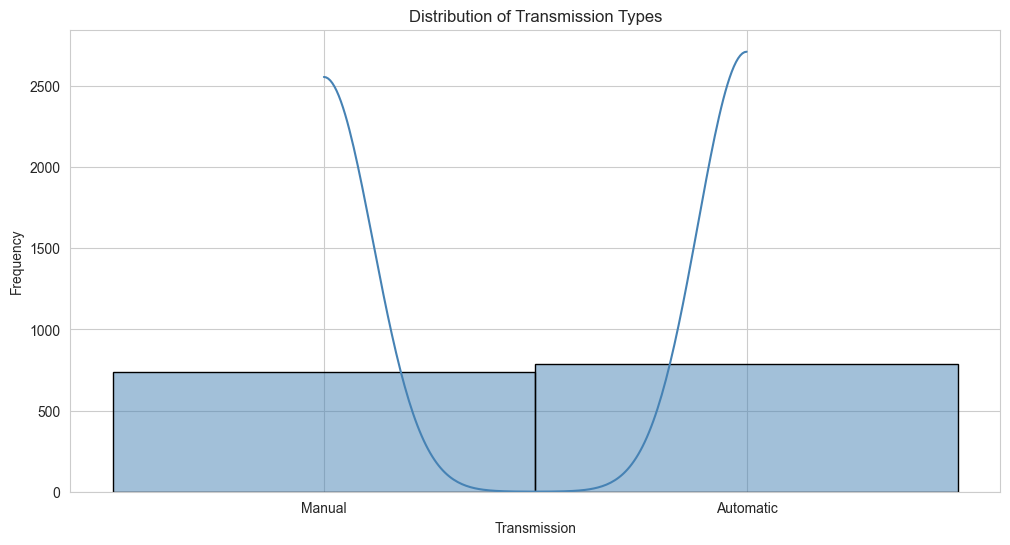

Transmission
Automatic    784
Manual       739
Name: count, dtype: int64 



In [90]:
print(f'{df["Transmission"].describe()} \n')


sns.histplot(df["Transmission"], bins=40, kde=True, color='steelblue', edgecolor='black')
plt.title('Distribution of Transmission Types')
plt.xlabel('Transmission')
plt.ylabel('Frequency')
plt.show()

print(f'{df["Transmission"].value_counts()} \n')